# SMS spam detector

AT&T Inc., an American multinational telecommunications holding company, is looking for an automated way of detecting spams to protect their users.

The goal of this project is to build a spam detector, which automatically flags spams based on the sms content.

We will build two text classification models using deep learning techniques:
- a simple deep learning model;
- a model using transfer learning;

This project will follow these steps:
- explanatory data analysis
- preprocessing
- model training;
- evaluation and comparison of the differents models' performance.

In [1]:
!pip install spacy plotly==5.17.0 contractions kaleido==0.2.1 tiktoken torchinfo transformers evaluate

!python -m spacy download en_core_web_sm

!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 34.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Import librairies
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import re
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import normalize
import plotly.express as px
from collections import Counter
import contractions
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torchinfo import summary
from collections import Counter
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, Trainer, TrainingArguments
from datasets import Dataset as HFDataset
import evaluate
from google.colab import drive
import kaleido

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"Device disponible: {'GPU' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.9.0+cu126
Device disponible: GPU


In [4]:
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Path to the project folder
PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/spam_detector"

# Create subfolders
os.makedirs(f"{PROJECT_PATH}/exports", exist_ok=True)

# 1. Explanatory data analysis

In [6]:
filename = "https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Deep+Learning/project/spam.csv"
df = pd.read_csv(filename, encoding='cp1252')


In [7]:
df.head(20)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [9]:
print(f"Shape of the dataframe: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"The dataset contains {len(df.loc[df.duplicated()])} exact duplicates.")

Shape of the dataframe: 5572 rows, 5 columns
The dataset contains 403 exact duplicates.


In [10]:
# Display duplicated observations
df.loc[df.duplicated(keep=False)]

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN
11,spam,"SIX chances to win CASH! From 100 to 20,000 po...",NaN,NaN,NaN
...,...,...,...,...,...
5524,spam,You are awarded a SiPix Digital Camera! call 0...,NaN,NaN,NaN
5535,ham,"I know you are thinkin malaria. But relax, chi...",NaN,NaN,NaN
5539,ham,Just sleeping..and surfing,NaN,NaN,NaN
5553,ham,Hahaha..use your brain dear,NaN,NaN,NaN


In [11]:
# Remove exact duplicates
df = df.loc[~df.duplicated()]

print(f"Shape of the dataframe: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"The dataset contains {len(df.loc[df.duplicated()])} exact duplicates.")

Shape of the dataframe: 5169 rows, 5 columns
The dataset contains 0 exact duplicates.


In [12]:
# Display some observations where "Unnamed" variables are not null
df.loc[df['Unnamed: 2'].notnull()].head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN


In [13]:
# Concatenate the content of "Unnamed" columns with "v2"
df['text'] = df[['v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']].astype(str).agg(' '.join, axis=1)

In [14]:
# Delete "nan" or "None"
df['text'] = df['text'].str.replace('None', '')
df['text'] = df['text'].str.replace('nan', '')

In [15]:
df.loc[df['Unnamed: 2'].notnull()].head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,text
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN,Your free ringtone is waiting to be collected....
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve..""",\Wen u miss someone the person is definitely ...
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN,SMS. ac sun0819 posts HELLO:\You seem cool wa...
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN,Height of Confidence: All the Aeronautics prof...


In [16]:
# Delete the "Unnamed" and "v2" columns which are now useless
df = df.loc[:, ~(df.columns.str.startswith('Unnamed')|(df.columns == 'v2'))]

In [17]:
df.head()

,v1,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
df = df.rename(columns={'v1':'label'})

In [19]:
df_detect = df['label'].value_counts().reset_index()
df_detect['proportion'] = round(df_detect['count'] / df_detect['count'].sum() * 100, 2)
df_detect

,label,count,proportion
0,ham,4516,87.37
1,spam,653,12.63


In [20]:
fig = px.pie(
    df,
    names='label'
)

fig.update_layout(
    height=400,
    width=600,
    title='Repartition of sms type',
    title_x=0.5
)

fig.show()

In [21]:
fig.write_image(f"{PROJECT_PATH}/exports/repartition_sms.png")

The dataset shows class imbalance in the target variable: 12.6% of the sms are spams.

# 2. Preprocessing

The preprocessing step involves:
- cleaning text;
- encoding labels into integers;
- split dataset between validation, training and test sets.

## 2.1. Text cleaning
We define a function which performs text cleaning:
- expanding contractions (for instance, "we're" is replaced by "we are")
- replacing structured entities such as numbers, URLs, phone numbers, emails with placeholder tokens (<NUM>, <URL>, <PHONE>, <EMAIL>)
- removing punctuation and deleting multiple spaces
- lowercasing the text
- removing stop words, which do not hold significant semantic meaning
- lemmatizing the text

In [22]:
nlp = spacy.load("en_core_web_sm")

def clean_text(text):

    # expand contractions
    text = contractions.fix(text)

    # replace structured entities (numbers, URLs, phone numbers, emails) with placeholder tokens
    text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' EMAILTOKEN ', text)
    text = re.sub(r'\b(?:https?://|www\.)\S+\b', ' URLTOKEN ', text)
    text = re.sub(r'\b(?:\+?\d[\d\-\s]{6,}\d)\b', ' PHONETOKEN ', text)
    text = re.sub(r'\b\d{1,3}(?:,\d{3})*(?:\.\d+)?\b', ' NUMTOKEN ', text) # identifies either 200 or 20,000 as numbers

    # remove punctuation while preserving placeholder tokens
    text = re.sub(
        r'EMAILTOKEN|URLTOKEN|PHONETOKEN|NUMTOKEN|[^\w\s]',
        lambda m: m.group(0) if m.group(0) in ['EMAILTOKEN', 'URLTOKEN', 'PHONETOKEN', 'NUMTOKEN'] else ' ',
        text
    )

    # keep alphanumeric characters and basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s\.,;:!?\'"()-]', '', text)

    # delete multiple spaces
    text = re.sub(r'\s+', ' ', text)

    # lowercase and delete leading and trailing spaces
    text = text.lower().strip()

    # removal of stop words and lemmatization
    doc = nlp(text)
    text = ' '.join([token.lemma_ for token in doc if token.text not in STOP_WORDS and not token.is_punct])

    # convert placeholders into <email>, <url>, <phone>, <num>
    text = text.replace('emailtoken', '<email>')
    text = text.replace('urltoken', '<url>')
    text = text.replace('phonetoken', '<phone>')
    text = text.replace('numtoken', '<num>')

    return text

In [23]:
df['text_clean'] = df['text'].apply(clean_text)

In [24]:
# Remove observations with empty values of text_clean
print(f"Number of observations before filtering: {len(df)}")
df = df.loc[df['text_clean'].str.strip() != ''].copy()
print(f"Number of observations after filtering: {len(df)}")

Number of observations before filtering: 5169
Number of observations after filtering: 5148


In [25]:
df.head(20)

,label,text,text_clean
0,ham,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry <num> wkly comp win fa cup final tk...
3,ham,U dun say so early hor... U c already then say...,dun early hor c
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think go usf live
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darle <num> week s word like fun t...
6,ham,Even my brother is not like to speak with me. ...,brother like speak treat like aids patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,request melle melle oru minnaminunginte nurung...
8,spam,WINNER!! As a valued network customer you have...,winner value network customer select receivea ...
9,spam,Had your mobile 11 months or more? U R entitle...,mobile <num> month r entitled update late colo...


## 2.2. Encoding labels into integers
`spam` maps to 1 and `ham` maps to 0.

In [26]:
df['label'] = df['label'].map({'ham':0, 'spam':1})

## 2.3. Split the dataset into training, validation and test sets

We split the dataset into training, validation and test sets with the following proportions : 60% (train), 20% (validation), 20% (test).

In [27]:
X = df['text_clean']
Y = df['label']

# Split train vs (validation + test)
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y,
    test_size=0.4,
    stratify=Y,
    random_state=0
)

# Split validation vs test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.5,
    stratify=Y_temp,
    random_state=0
)

print(f"Train set : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set : {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Train set : 3088 (60.0%)
Validation set : 1030 (20.0%)
Test set: 1030 (20.0%)


# 3. A simple deep learning model

## 3.1. Tokenization

Before training the model, we go through the step of tokenization, which converts the text data into a format that the model can understand.

We perform index-based encoding: each token of the vocabulary is assigned to an index (integer), and each text is transformed into a sequence of indices.  

As our baseline model is a simple model (not a pre-trained model), we will first use a simple tokenizer (which splits text based on spaces).
When we create the vocabulary of our training set, we insert two special tokens:
- $<PAD>$: a padding token in order to ensure that all text sequences have the same length;
- $<UNK>$: a token for out-of-vocabulary words: words that are not in the training set, to allow the model to handle words in the test set which were unseen during the training phase.

Then we encode the sequences of tokens into sequences of integers. The sequences need to be the same length, so we use padding/truncation.

In [28]:
# Define a simple tokenizer
def tokenizer(text):
    return text.split()

In [29]:
# Tokenize texts
X_train_tokens = [tokenizer(text) for text in X_train]
X_val_tokens = [tokenizer(text) for text in X_val]
X_test_tokens = [tokenizer(text) for text in X_test]

# Build the vocabulary using the already tokenized training set
all_tokens = []
for tokens in X_train_tokens:
    all_tokens.extend(tokens)

# Create the vocabulary (most frequent words have smaller indices)
counter = Counter(all_tokens)
vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common())}

# Special tokens (padding and unknown words)
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

print(f"Number of tokens: {len(all_tokens)}")
print(f"Vocabulary size: {len(vocab)}")

Number of tokens: 25095
Vocabulary size: 5094


In [30]:
print(all_tokens[:100])

['bank', 'money', 'babe', 'talk', 'think', 'good', 'boy', 'miss', 'love', 'oh', 'great', 'll', 'disturb', 'talk', 'need', 'stop', 'go', 'bed', 'fucking', 'dealing', 'chance', 'win', 'free', 'bluetooth', 'headset', 'simply', 'reply', 'adp', 'course', 'guess', 'god', 's', 'get', 'hold', 'right', 'oh', 'k', 'placement', 'ah', 'tall', 'princess', 'pls', 'accept', 'day', 'beg', 'change', 'number', 'good', 'afternoon', 'love', 'go', 'day', 'wake', 'early', 'online', 'wait', 'hmmm', 'italian', 'boy', 'online', 'grin', 'ok', 'money', 'r', 'lucky', 'winner', '<num>', 'claim', 'prize', 'text', 'money', '<num>', '88600', '1million', 'away', 'ppt150x3', 'normal', 'text', 'rate', 'box403', 'w1t1jy', 'common', 'hearin', 'r', 'wat', 'r', 'day', 'let', 'ask', 'different', 'smile', 'today', 'gud', 'evng', 'sure', 'alex', 'know', 'birthday', 'minute', 'far']


In [31]:
# Encoding sequences of tokens into sequences of integers
# Define a function which converts lists of tokens into lists of indices

def tokens_to_indices(tokens, vocab):
    """
    tokens : list of tokens
    vocab : dictionary {token: index}
    """
    indices = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    return indices

# Apply this function to the training and the test sets
X_train_indices = [tokens_to_indices(tokens, vocab) for tokens in X_train_tokens]
X_val_indices = [tokens_to_indices(tokens, vocab) for tokens in X_val_tokens]
X_test_indices = [tokens_to_indices(tokens, vocab) for tokens in X_test_tokens]

print(f"Train set: {len(X_train_indices)} sequences")
print(f"Validation set: {len(X_val_indices)} sequences")
print(f"Test set: {len(X_test_indices)} sequences")

Train set: 3088 sequences
Validation set: 1030 sequences
Test set: 1030 sequences


In [32]:
# Each sequence must have the same length in order to build the DataLoader
# We calculate some descriptive statistics of the senquence length, in order to decide which length we want all sequences to adopt

seq_len = [len(seq) for seq in X_train_tokens]
print(f"Average sequence length: {np.mean(seq_len):.2f}")
print(f"Median sequence length: {np.median(seq_len):.2f}")
print(f"Maximum sequence length: {np.max(seq_len):.2f}")
print(f"Standard deviation: {np.std(seq_len):.2f}")
print(f"Minimum: {np.min(seq_len)}")
print(f"Maximum: {np.max(seq_len)}")
print(f"75th percentile: {np.percentile(seq_len, 75):.2f}")
print(f"90th percentile: {np.percentile(seq_len, 90):.2f}")
print(f"95th percentile: {np.percentile(seq_len, 95):.2f}")
print(f"99th percentile: {np.percentile(seq_len, 99):.2f}")

Average sequence length: 8.13
Median sequence length: 6.00
Maximum sequence length: 73.00
Standard deviation: 6.37
Minimum: 1
Maximum: 73
75th percentile: 11.00
90th percentile: 17.00
95th percentile: 20.00
99th percentile: 26.13


We choose to use the 99th percentile for our sequence length: 26 tokens.

In [33]:
# We define the maximal length of a sequence
max_len = 26

In [34]:
# We adjust the length using padding/truncation.
# Truncation :long sequences are cut shorter
# Padding: shorter sequences neede to be lengthened. We fill the missing spots with `0` until the sequence reaches the desired length.

def pad_sequences(sequences, max_length=max_len, pad_value=vocab["<PAD>"]):
    padded = []
    for seq in sequences:
        if len(seq) < max_length:
            seq = seq + [pad_value] * (max_length - len(seq))
        else:
            seq = seq[:max_length]
        padded.append(seq)
    return padded

X_train_padded = pad_sequences(X_train_indices, max_length=max_len, pad_value=vocab["<PAD>"])
X_val_padded = pad_sequences(X_val_indices, max_length=max_len, pad_value=vocab["<PAD>"])
X_test_padded = pad_sequences(X_test_indices,  max_length=max_len, pad_value=vocab["<PAD>"])

In [35]:
# Check

print("Examples before and after padding:")
for i in range(3):
    print(f"\nSequence {i+1}:")
    print(f"Before padding: {X_train_indices[i]} (length: {len(X_train_indices[i])})")
    print(f"After padding: {X_train_padded[i]} (length: {len(X_train_padded[i])})")

Examples before and after padding:

Sequence 1:
Before padding: [522, 93] (length: 2)
After padding: [522, 93, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] (length: 26)

Sequence 2:
Before padding: [79, 103, 23, 10, 195, 46, 12] (length: 7)
After padding: [79, 103, 23, 10, 195, 46, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] (length: 26)

Sequence 3:
Before padding: [52, 71, 118, 590, 103] (length: 5)
After padding: [52, 71, 118, 590, 103, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] (length: 26)


## 3.2. Instantiating the Pytorch Dataset
We create a custom dataset class and define three functions inherited from Pytorch's Dataset class.

In [36]:
# Define a custom PyTorch dataset class for the dataset

class SpamDatasetPytorch(TorchDataset):
    """
    A custom dataset class for SMS dataset.

    This class is used to convert text data (already tokenized) and their corresponding labels
    into a PyTorch Dataset object, which can be easily loaded into a DataLoader.
    """

    def __init__(self, texts, labels):
        """
        Initializes the dataset by storing texts and labels as PyTorch tensors.

        Args:
        - texts (list or numpy array): Tokenized text data, where each text has been converted into a sequence of word indices (integer tokens).
        - labels (list or numpy array): The corresponding labels for each text.
        """
        # Convert text sequences to a PyTorch tensor (long type since they are indices)
        self.texts = torch.tensor(texts, dtype=torch.long)

        # Convert labels to a PyTorch tensor (float32 for compatibility with loss functions)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        """
        Returns the total number of samples in the dataset.

        This method is required for PyTorch datasets as it allows DataLoader to determine how many batches it needs.
        """
        return len(self.texts)

    def __getitem__(self, idx):
        """
        Retrieves a single data point (text and label) from the dataset based on an index.

        Args:
        - idx (int): Index of the sample to retrieve.

        Returns:
        - tuple: A tuple containing:
            - self.texts[idx]: The tokenized text at index `idx`.
            - self.labels[idx]: The corresponding label for that text.
        """
        return self.texts[idx], self.labels[idx]

In [37]:
# Creating dataset instances
train_dataset = SpamDatasetPytorch(X_train_padded, Y_train.tolist())
val_dataset = SpamDatasetPytorch(X_val_padded, Y_val.tolist())
test_dataset = SpamDatasetPytorch(X_test_padded, Y_test.tolist())

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [38]:
# Inspect a batch of the train DataLoader
text, label = next(iter(train_loader))
print(label)
print(text)

tensor([0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([[3197, 1350,  150,   71,   14,  863,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0],
        [  51,  115,   39,  221,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0],
        [  11,   35,  219,   37,    2,  409,  220,   59,  200,  301,  214,  670,
           15,   19,    2,  149,   39,    3,   15,  379,    0,    0,    0,    0,
            0,    0],
        [2719,  208, 2720,   65, 2721, 2722,  164, 2723, 2724,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0],
        [ 285,   10,   80,   49,   10,  228,   87,   57,    5,  238, 1078,    9,
            8,  210,   48,  759,  404,

# 3.3. Model training

We create a simple classification model with 3 layers (embedding, average pooling, fully connected) :
- Embedding layer : converts token indices into vectors (embeddings)
- Adaptive average pooling : computes the average of the embeddings to obtain a fixed-sized vector
- Fully connected layer : transforms the vector into a logit score used for classification


In [39]:
# Get the vocabulary size from the tokenizer
# It represents the total number of unique words in the dataset, which will be used as the input size for the embedding layer.
vocab_size = len(vocab)

In [40]:
# Define the embeddings dimension
embed_dim = 32

In [41]:
# Define a neural network model for text classification
class SpamClassifier(nn.Module):
    """
    A simple text classification model using embeddings and pooling.

    This model takes tokenized text as input and predicts a class (0 for ham, 1 for spam).
    """

    def __init__(self, vocab_size, embed_dim, num_class=1
                 ,dropout_rate=0.3
                 ):
        """
        Initializes the model layers for text classification.

        Args:
        - vocab_size (int): the number of unique words in the vocabulary.
        - embed_dim (int): the size of each word's embedding vector.
        - num_class (int): the number of output classes. For binary classification (spam/ham), it is equal to 1.

        The model consists of:
        1. An embedding layer that converts tokenized words into dense vectors.
        Uses padding_idx=0 so that padding tokens do not contribute to learning.
        2. An Adaptive Average Pooling layer that reduces the sequence length by averaging word embeddings,
        producing a fixed-size representation regardless of input length.
        3. A fully Connected (Linear) layer that maps the pooled embeddings to a single logit.
        4. A Sigmoid activation that converts the logit into a probability between 0 and 1.

        The output is suitable for binary classification with `nn.BCELoss`.
        """
        super(SpamClassifier, self).__init__()

        # Embedding layer: Maps word indices to dense vector representations
        # padding_idx=0 ensures that padding tokens (index 0) do not contribute to learning
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Dropout layer to prevent overfitting
        self.dropout = nn.Dropout(dropout_rate)

        # Adaptive Average Pooling layer
        self.pooling = nn.AdaptiveAvgPool1d(1)

        # Fully Connected (Linear) layer
        self.fc = nn.Linear(embed_dim, num_class)

    def forward(self, text):
        """
        Defines the forward pass of the model.

        Args:
        - text (Tensor): A batch of tokenized text sequences
                        of shape (batch_size, sequence_length),
                        where each element is a word index.

        Returns:
        - Tensor: Batch of probabilities of shape (batch_size, 1),
                representing the predicted probability of the positive class (spam).
        """
        # Convert input word indices into dense embeddings
        embedded = self.embedding(text)

        # Permute to match the expected shape for pooling: (batch, channels, sequence_length)
        # Then, apply average pooling to reduce sequence length to 1
        pooled = self.pooling(embedded.permute(0, 2, 1)).squeeze(2)

        # Apply dropout to prevent overfitting (only active during training)
        pooled = self.dropout(pooled)

        # Pass the pooled embeddings through the linear layer and the sigmoid activation function
        return torch.sigmoid(self.fc(pooled))

In [42]:
# Create an instance of the model
model = SpamClassifier(vocab_size=vocab_size, embed_dim=embed_dim, num_class=1)

In [43]:
# Print out the structure of the model
print(model)

# Number of parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total number of parameters: {total_params:,}")
print(f"Number of trainable parameters: {trainable_params:,}")

for name, param in model.named_parameters():
    print(f"- {name}: {param.numel():,} parameters")

summary(model, input_data=text)  # (batch_size, input_features)

SpamClassifier(
  (embedding): Embedding(5094, 32, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (pooling): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Total number of parameters: 163,041
Number of trainable parameters: 163,041
- embedding.weight: 163,008 parameters
- fc.weight: 32 parameters
- fc.bias: 1 parameters


Layer (type:depth-idx)                   Output Shape              Param #
SpamClassifier                           [32, 1]                   --
├─Embedding: 1-1                         [32, 26, 32]              163,008
├─AdaptiveAvgPool1d: 1-2                 [32, 32, 1]               --
├─Dropout: 1-3                           [32, 32]                  --
├─Linear: 1-4                            [32, 1]                   33
Total params: 163,041
Trainable params: 163,041
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 5.22
Input size (MB): 0.01
Forward/backward pass size (MB): 0.21
Params size (MB): 0.65
Estimated Total Size (MB): 0.87

In [44]:
# Prepare and run the model for 20 epochs

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train(model, train_loader, val_loader, criterion, optimizer, epochs=100, device=None):
    """
    Function to train a PyTorch model with training and validation datasets.

    Parameters:
    model: The neural network model to train.
    train_loader: DataLoader for the training dataset.
    val_loader: DataLoader for the validation dataset.
    criterion: Loss function (e.g., Binary Cross Entropy for classification).
    optimizer: Optimization algorithm (e.g. Adam, SGD).
    epochs: Number of training epochs (default=100).
    device: 'cpu' or 'cuda' to run training on GPU if available.

    Returns:
    history: Dictionary containing loss and accuracy for both training and validation.
    """
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Dictionary to store training & validation loss and accuracy over epochs
    history = {k: [] for k in [
        'train_loss', 'val_loss',
        'train_accuracy', 'val_accuracy',
        'train_precision', 'val_precision',
        'train_recall', 'val_recall',
        'train_f1', 'val_f1'
    ]}

    for epoch in range(epochs):  # Loop over the number of epochs
        # ---- TRAINING ----
        model.train()  # Set model to training mode
        total_loss = 0  # Initialize total loss

        # Lists to store predictions and true labels for metric calculation
        train_preds = []
        train_labels = []

        # Training loop
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.float().to(device)
            optimizer.zero_grad()  # Reset gradients before each batch
            outputs = model(inputs).squeeze()  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backpropagation (compute gradients)
            optimizer.step()  # Update model parameters

            total_loss += loss.item()  # Accumulate batch loss

            # Store predictions and labels for metrics
            train_preds.extend((outputs > 0.5).int().detach().cpu().numpy())
            train_labels.extend(labels.int().detach().cpu().numpy())

        # Compute training metrics
        train_loss = total_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)
        train_precision = precision_score(train_labels, train_preds, zero_division=0)
        train_recall = recall_score(train_labels, train_preds, zero_division=0)
        train_f1 = f1_score(train_labels, train_preds, zero_division=0)

        # ---- VALIDATION ----
        # Validation phase (without gradient computation)
        model.eval()  # Set model to evaluation mode
        val_loss = 0

        # Lists to store validation predictions and true labels
        val_preds = []
        val_labels = []

        with torch.no_grad():  # No need to compute gradients during validation
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.float().to(device)
                outputs = model(inputs).squeeze()  # Forward pass
                loss = criterion(outputs, labels)  # Compute loss
                val_loss += loss.item()  # Accumulate validation loss

                # Store predictions and labels for metrics
                val_preds.extend((outputs > 0.5).int().detach().cpu().numpy())
                val_labels.extend(labels.int().detach().cpu().numpy())

        # Compute average loss and validation metrics
        val_loss /= len(val_loader)
        val_acc = accuracy_score(val_labels, val_preds)
        val_precision = precision_score(val_labels, val_preds, zero_division=0)
        val_recall = recall_score(val_labels, val_preds, zero_division=0)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)

        # Store metrics in history dictionary
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)
        history['train_precision'].append(train_precision)
        history['val_precision'].append(val_precision)
        history['train_recall'].append(train_recall)
        history['val_recall'].append(val_recall)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        # Print training progress
        print(f"Epoch [{epoch+1}/{epochs}] "
                f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}, Train Precision: {train_precision:.4f}, "
                f"Train Recall: {train_recall:.4f}, Train F1: {train_f1:.4f} | "
                f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}, Val Precision: {val_precision:.4f}, "
                f"Val Recall: {val_recall:.4f}, Val F1: {val_f1:.4f}")

    return history

history = train(model,
                train_loader=train_loader,
                val_loader=val_loader,
                criterion=criterion,
                optimizer=optimizer,
                epochs=20)

Epoch [1/20] Train Loss: 0.7275, Train Accuracy: 0.2267, Train Precision: 0.1228, Train Recall: 0.8291, Train F1: 0.2140 | Val Loss: 0.7011, Val Accuracy: 0.3816, Val Precision: 0.1416, Val Recall: 0.7634, Val F1: 0.2389
Epoch [2/20] Train Loss: 0.6685, Train Accuracy: 0.6538, Train Precision: 0.2158, Train Recall: 0.6556, Train F1: 0.3247 | Val Loss: 0.6398, Val Accuracy: 0.8709, Val Precision: 0.4926, Val Recall: 0.5115, Val F1: 0.5019
Epoch [3/20] Train Loss: 0.6030, Train Accuracy: 0.8941, Train Precision: 0.5761, Train Recall: 0.6276, Train F1: 0.6007 | Val Loss: 0.5721, Val Accuracy: 0.9262, Val Precision: 0.8571, Val Recall: 0.5038, Val F1: 0.6346
Epoch [4/20] Train Loss: 0.5289, Train Accuracy: 0.9417, Train Precision: 0.8581, Train Recall: 0.6480, Train F1: 0.7384 | Val Loss: 0.4953, Val Accuracy: 0.9417, Val Precision: 0.9733, Val Recall: 0.5573, Val F1: 0.7087
Epoch [5/20] Train Loss: 0.4517, Train Accuracy: 0.9582, Train Precision: 0.9550, Train Recall: 0.7041, Train F1: 0.

In [45]:
def plot_metrics(history):
    """
    Plots training and validation metrics
    """
    # Transforms the dictionary into a dataframe
    df = pd.DataFrame(history)
    df['epoch'] = df.index + 1

    # Loss visualisation
    df_loss = df[['epoch', 'train_loss', 'val_loss']].dropna()
    fig_loss = px.line(df_loss, x='epoch', y=['train_loss', 'val_loss'],
                        title='Loss over epochs',
                        labels={'value': 'Loss', 'variable': 'Dataset', 'epoch': 'Epoch'})

    fig_loss.update_layout(
        xaxis_title='Epoch',
        yaxis_title='Loss',
        legend_title='Dataset',
        height=500,
        width=800
    )

    fig_loss.show()

    # Visualization for the other metrics
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']

    train_cols = [f'train_{m}' for m in metrics_to_plot]
    val_cols = [f'val_{m}' for m in metrics_to_plot]
    all_cols = ['epoch'] + train_cols + val_cols

    df_metrics = df[all_cols].dropna()

    # Convert into long format
    df_metrics_long = df_metrics.melt(id_vars='epoch', var_name='metric', value_name='value')

    # Type of dataset (train/validation)
    df_metrics_long['dataset'] = df_metrics_long['metric'].apply(
        lambda x: 'validation' if x.startswith('val_') else 'train'
    )
    df_metrics_long['metric'] = df_metrics_long['metric'].str.replace('train_', '', regex=False)
    df_metrics_long['metric'] = df_metrics_long['metric'].str.replace('val_', '', regex=False)

    # Filter the metrics to plot
    df_metrics_long = df_metrics_long[df_metrics_long['metric'].isin(metrics_to_plot)]

    # Define plot
    fig_metrics = px.line(df_metrics_long, x='epoch', y='value', color='metric', line_dash='dataset',
                          title='Performance metrics over epochs',
                          labels={'value': 'Metric value', 'metric': 'Metric', 'epoch': 'Epoch'})

    fig_metrics.update_layout(
        xaxis_title='Epoch',
        yaxis_title='Metric Value',
        legend_title='Metric',
        height=600,
        width=800
    )

    fig_metrics.show()

    return fig_loss, fig_metrics

In [46]:
fig_loss, fig_metrics = plot_metrics(history)

In [47]:
fig_loss.write_image(f"{PROJECT_PATH}/exports/training_loss_baseline.png")
fig_metrics.write_image(f"{PROJECT_PATH}/exports/training_metrics_baseline.png")

## 3.4. Model evaluation

We compute the main metrics: accuracy, precision, recall, F1-score.

In the context of spam detection with imbalanced classes, focusing only on accuracy can be misleading, since a model which always predicts "ham" will be considered as performant.

We will focus on **precision** (it is more problematic to miss a ham and mark it as illegitimate) while keeping a reasonable recall in order not to let too much spams.

We also can look at the F1-score if we want a balance between false positives and false negatives.

In [48]:
def evaluate_model(model, test_loader, device=None):
    """
    Evaluate the model on the test dataset.

    Returns a dictionary with loss, accuracy, precision, recall, F1, and AUC.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()  # Evaluation mode

    criterion = nn.BCELoss()  # Same loss as during training

    all_preds, all_labels = [], []
    total_loss = 0
    total_samples = 0

    with torch.no_grad():  # No gradients needed
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.float().to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            # Accumulate loss (weighted by batch size)
            batch_size = inputs.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            # Store predictions, probabilities, and labels
            preds = (outputs > 0.5).float()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # Compute metrics using scikit-learn
    metrics = {
        "loss": total_loss / total_samples,
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0)
    }

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    return metrics, cm

In [49]:
test_metrics, test_cm = evaluate_model(model, test_loader, device=None)
print(test_metrics)
print("Confusion matrix:\n", test_cm)

{'loss': 0.11941383536000853, 'accuracy': 0.9815533980582525, 'precision': 0.9826086956521739, 'recall': 0.8692307692307693, 'f1': 0.9224489795918367}
Confusion matrix:
 [[898   2]
 [ 17 113]]


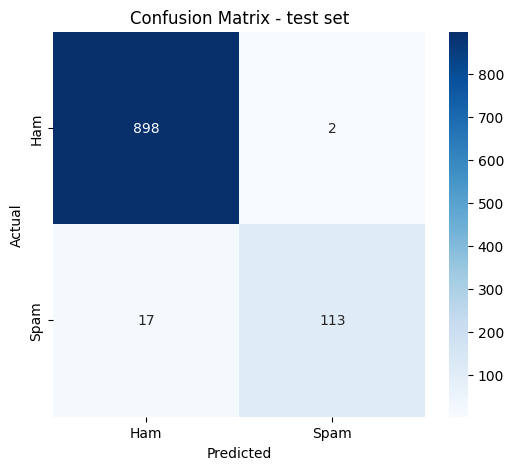

In [50]:
plt.figure(figsize=(6,5))
sns.heatmap(test_cm, annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - test set')
plt.show()

In [51]:
# Store results
model_results = {}

metrics1, _ = evaluate_model(model, test_loader, device=None)
model_results["Baseline model"] = {
    "accuracy": metrics1["accuracy"],
    "f1": metrics1["f1"],
    "precision": metrics1["precision"],
    "recall": metrics1["recall"],
}

model_results

{'Baseline model': {'accuracy': 0.9815533980582525,
  'f1': 0.9224489795918367,
  'precision': 0.9826086956521739,
  'recall': 0.8692307692307693}}

# 4. Transfer learning

We build a spam detection model by using a pre-trained one: the **DistilBERT** model.

This model is available from Hugging Face Transformers library.

The preprocessing will change from the previous models: we will use the tokenizer from the pretrained model.

## 4.1. Preprocessing

In [52]:
def clean_text_light(text):

    # delete multiple spaces
    text = re.sub(r'\s+', ' ', text)

    # delete leading and trailing spaces
    text = text.strip()

    return text

In [53]:
df['text_clean_light'] = df['text'].apply(clean_text_light)

In [54]:
X = df['text_clean_light']
Y = df['label']

# Split train vs (validation + test)
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y,
    test_size=0.4,
    stratify=Y,
    random_state=0
)

# Split validation vs test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.5,
    stratify=Y_temp,
    random_state=0
)

print(f"Train set : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set : {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Train set : 3088 (60.0%)
Validation set : 1030 (20.0%)
Test set: 1030 (20.0%)


## 4.2. Tokenization
We load the DistilBERT Tokenizer (from Hugging Face AutoTokenizer) and map it over our training, validation and test datasets.  

In [55]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



In [56]:
# Define a function to tokenize text
def tokenize_text(example):
    return tokenizer(example["text_clean_light"], padding=True, truncation=True)

In [57]:
# Crate datasets using Hugging Face Dataset
train_dataset = HFDataset.from_dict({
    "text_clean_light": X_train.tolist(),
    "labels": Y_train.tolist()
})

val_dataset = HFDataset.from_dict({
    "text_clean_light": X_val.tolist(),
    "labels": Y_val.tolist()
})

test_dataset = HFDataset.from_dict({
    "text_clean_light": X_test.tolist(),
    "labels": Y_test.tolist()
})

# Apply tokenization over the dataset using the [`Dataset.map()`](https://huggingface.co/docs/datasets/package_reference/main_classes#datasets.Dataset.map) method
train_tokenized = train_dataset.map(tokenize_text, batched=True)
val_tokenized = val_dataset.map(tokenize_text, batched=True)
test_tokenized = test_dataset.map(tokenize_text, batched=True)

Map:   0%|          | 0/3088 [00:00<?, ? examples/s]

Map:   0%|          | 0/1030 [00:00<?, ? examples/s]

Map:   0%|          | 0/1030 [00:00<?, ? examples/s]

The padding will be dynamically applied, on each batch of examples, using a _collate function_. This function will apply the correct amount of padding to the items of the dataset we want to batch together. The Hugging Face Transformers library provides with such a function via `DataCollatorWithPadding`.

In [58]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [59]:
# Setting up evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average='binary'),
        "precision": precision_score(labels, predictions, average='binary'),
        "recall": recall_score(labels, predictions, average='binary'),
    }

## 4.2. Model training
We fine-tune the DistilBERT model for our classification problem.

The first step before we can define our `Trainer` is to define a `TrainingArguments` class that will contain all the hyperparameters the `Trainer` will use for training and evaluation. The only argument to provide is a directory where the trained model will be saved, as well as the checkpoints along the way.

In [60]:
# Create a map of the expected ids to their labels with id2label and label2id
id2label = {0: "ham", 1:"spam"}
label2id = {"ham": 0, "spam": 1}

In [61]:
# Instantiate the pre-trained model to use
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [62]:
# Define the training hyperparameters in TrainingArguments. We use the default parameters
training_args = TrainingArguments("test-trainer",
                                eval_strategy="epoch",
                                save_strategy="epoch",
                                per_device_train_batch_size=32,
                                per_device_eval_batch_size=32,
                                num_train_epochs=3,
                                learning_rate=2e-5,
                                load_best_model_at_end=True,
                                metric_for_best_model="f1",
                                greater_is_better=True,
                                report_to=[]
    )

In [63]:
# Once we have our model, we can define a `Trainer` by passing it all the objects constructed up to now — the `model`, the `training_args`, the training and validation datasets, our `data_collator`, and our `tokenizer`:

trainer = Trainer(
    model,
    training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [64]:
os.environ["WANDB_DISABLED"] = "true"

In [65]:
# To fine-tune the model on our dataset, we just have to call the `train()` method of our `Trainer
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.043846,0.990291,0.960938,0.984000,0.938931
2,No log,0.041433,0.990291,0.960938,0.984000,0.938931
3,No log,0.041256,0.990291,0.960938,0.984000,0.938931


TrainOutput(global_step=291, training_loss=0.05704457653347159, metrics={'train_runtime': 192.9053, 'train_samples_per_second': 48.024, 'train_steps_per_second': 1.509, 'total_flos': 529699870769472.0, 'train_loss': 0.05704457653347159, 'epoch': 3.0})

In [66]:
# Save the model
output_dir = f"{PROJECT_PATH}/exports/spam-classifier-distilbert"
trainer.save_model(output_dir)

## 4.3. Model evaluation

In [67]:
# Evaluation on test set
test_results = trainer.evaluate(eval_dataset=test_tokenized)
print(test_results)

model_results["DistilBERT"] = {
    "accuracy": test_results["eval_accuracy"],
    "f1": test_results["eval_f1"],
    "precision": test_results["eval_precision"],
    "recall": test_results["eval_recall"],
}

print(f"Evaluation loss: {test_results['eval_loss']:.3f}")
print(f"Accuracy: {test_results['eval_accuracy']:.3f}")
print(f"F1 Score: {test_results['eval_f1']:.3f}")
print(f"Precision: {test_results['eval_precision']:.3f}")
print(f"Recall: {test_results['eval_recall']:.3f}")

{'eval_loss': 0.044289130717515945, 'eval_accuracy': 0.9864077669902913, 'eval_f1': 0.944, 'eval_precision': 0.9833333333333333, 'eval_recall': 0.9076923076923077, 'eval_runtime': 8.3764, 'eval_samples_per_second': 122.965, 'eval_steps_per_second': 3.94, 'epoch': 3.0}
Evaluation loss: 0.044
Accuracy: 0.986
F1 Score: 0.944
Precision: 0.983
Recall: 0.908


Classification report :
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       900
        spam       0.98      0.91      0.94       130

    accuracy                           0.99      1030
   macro avg       0.99      0.95      0.97      1030
weighted avg       0.99      0.99      0.99      1030



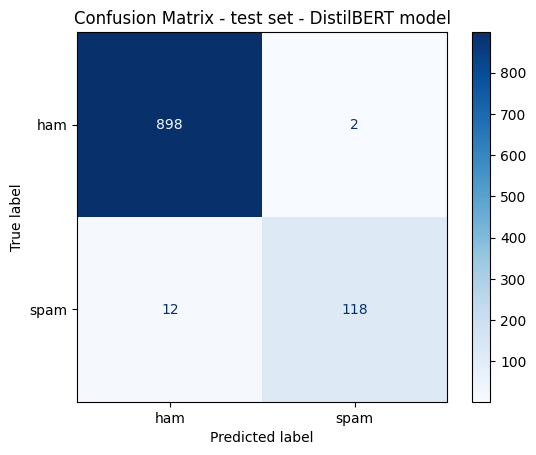

In [68]:
predictions = trainer.predict(test_tokenized)
preds = np.argmax(predictions.predictions, axis=-1)

# Classification report (test set)
report = classification_report(test_tokenized['labels'], preds, target_names=['ham', 'spam'])

print("Classification report :")
print(report)

# Confusion matrix (test set)
cm = confusion_matrix(test_tokenized['labels'], preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=id2label.values())
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - test set - DistilBERT model')
plt.show()

# 5. Model comparison

In [69]:
df_results = pd.DataFrame(model_results).T
display(df_results.round(3))

,accuracy,f1,precision,recall
Baseline model,0.982,0.922,0.983,0.869
DistilBERT,0.986,0.944,0.983,0.908


The DistilBERT model shows very good precision (precision of 98%, same as the baseline model). It outperforms the baseline model with improvements in recall and F1-score (reducing false negatives).

The drawback of using transfer learning is its execution time: on Google Colab, while the baseline model training takes only around 5 seconds, DistilBERT may require 3 minutes to complete the same task.

# 5. Conclusion

This project has shown the effectiveness of transfer learning for spam classification, with DistilBERT outperforming the baseline model.

Some paths of improvement can be identified:
- use RNN (recurrent neural network) models: implement LSTM or GRU models to capture sequential dependencies;
- optimization: hyperparameter tuning
- address the issue of class imbalance using resampling techniques (sucha as oversampling of spams, undersampling of hams)
- add contextual features such as the length of the messages, the number of uppercase words, the number of specific items such as emails and URLs.